# Dataset Facebook

### Load Dataset

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd

df = pd.read_csv("/content/drive/MyDrive/PPW/facebook_combined.txt", sep=' ', header=None)
df.head()

,0,1
0,0,1
1,0,2
2,0,3
3,0,4
4,0,5


## Graph Sederhana

Partisi komunitas: {'A': 0, 'B': 0, 'C': 0, 'D': 1, 'E': 1}
Modularity: 0.220


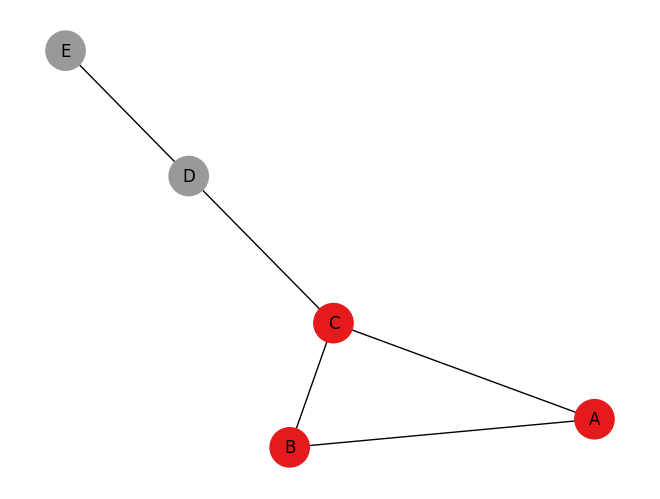

In [ ]:
!pip install python-louvain
import networkx as nx
from community import community_louvain
import matplotlib.pyplot as plt

# Graph contoh kecil
G = nx.Graph()
G.add_edges_from([
    ('A','B'), ('A','C'),
    ('B','C'),
    ('C','D'), ('D','E')
])

# Louvain
partition = community_louvain.best_partition(G)
mod = community_louvain.modularity(partition, G)

print("Partisi komunitas:", partition)
print(f"Modularity: {mod:.3f}")

# Visualisasi
pos = nx.spring_layout(G, seed=42)
nx.draw(
    G, pos,
    with_labels=True,
    node_color=[partition[n] for n in G.nodes()],
    cmap=plt.cm.Set1,
    node_size=800
)
plt.show()

## Analisis Komunitas

Total Node   : 4039
Total Edges  : 88234

Graph berhasil dimuat!

Menjalankan Louvain Community Detection...
Jumlah komunitas ditemukan: 16
Modularity Score          : 0.8349



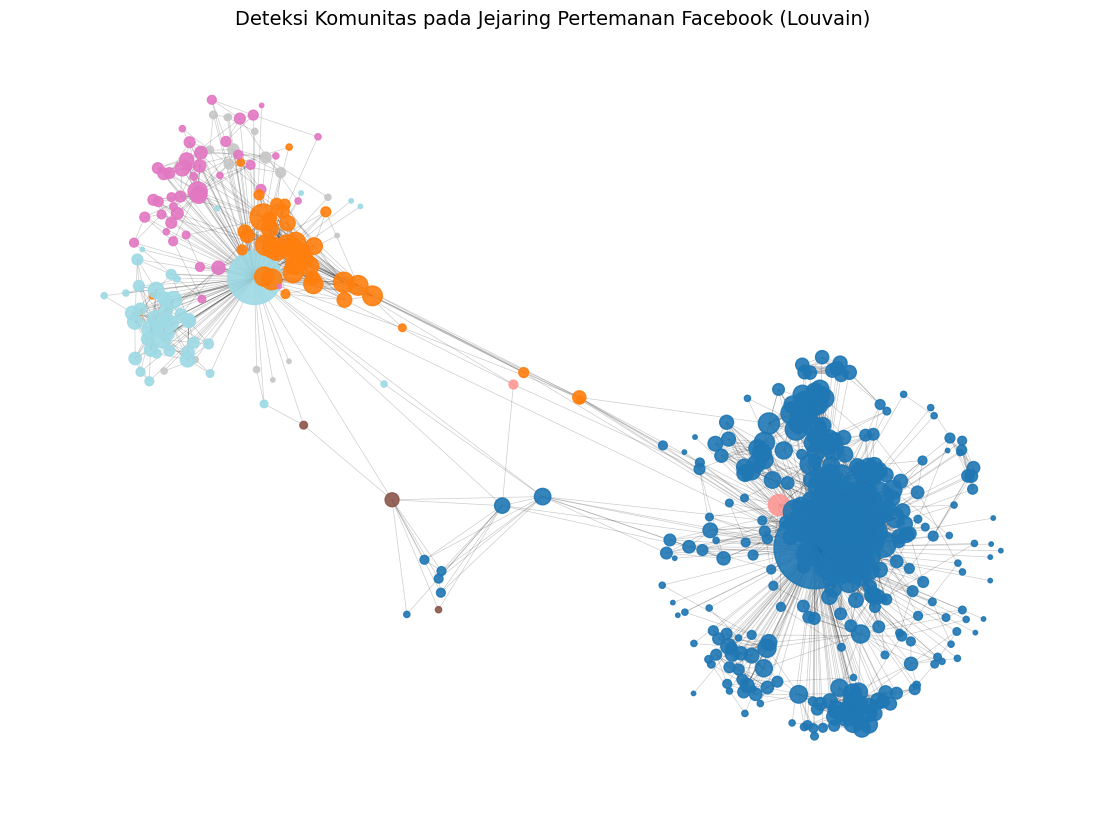

=== ANALISIS KOMUNITAS FACEBOOK ===

Top 10 komunitas berdasarkan jumlah anggota:
community
15    548
4     535
8     443
1     433
3     423
0     350
5     321
11    237
9     226
14    206
Name: count, dtype: int64


In [ ]:
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt
from community import community_louvain
import numpy as np

# Bangun graph
G = nx.from_pandas_edgelist(df, 0, 1)

print(f"Total Node   : {G.number_of_nodes()}")
print(f"Total Edges  : {G.number_of_edges()}")
print("\nGraph berhasil dimuat!\n")

# ======================================
# 2. DETEKSI KOMUNITAS (Louvain)
# ======================================
print("Menjalankan Louvain Community Detection...")

partition = community_louvain.best_partition(G)
modularity_value = community_louvain.modularity(partition, G)

print(f"Jumlah komunitas ditemukan: {len(set(partition.values()))}")
print(f"Modularity Score          : {modularity_value:.4f}\n")

# ======================================
# 3. VISUALISASI GRAPH (tidak sederhana)
#    Hanya ambil 500 node untuk menjaga performa visualisasi
# ======================================
sub_nodes = list(G.nodes())[:500]
H = G.subgraph(sub_nodes)

partition_sub = {n: partition[n] for n in H.nodes()}
node_degree = dict(H.degree())

plt.figure(figsize=(14, 10))
pos = nx.spring_layout(H, k=0.12, seed=42)

nx.draw_networkx_nodes(
H, pos,
    node_size=[node_degree[n] * 10 for n in H.nodes()],
    node_color=list(partition_sub.values()),
    cmap="tab20",
    alpha=0.9
)

nx.draw_networkx_edges(
H, pos,
    alpha=0.2,
    width=0.5
)

plt.title("Deteksi Komunitas pada Jejaring Pertemanan Facebook (Louvain)", fontsize=14)
plt.axis("off")
plt.show()

# ======================================
# 4. ANALISIS KOMUNITAS
# ======================================
print("=== ANALISIS KOMUNITAS FACEBOOK ===\n")

community_df = pd.DataFrame.from_dict(partition, orient='index', columns=['community'])
community_sizes = community_df['community'].value_counts()

print("Top 10 komunitas berdasarkan jumlah anggota:")
print(community_sizes.head(10))